In [6]:
!pip install pandas numpy matplotlib seaborn plotly tqdm -q
print("✅ Setup done")

✅ Setup done


In [7]:
from google.colab import drive
import pandas as pd
import os

drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/OSL_Research"

df_materials = pd.read_csv(BASE + "/osl_materials_unified.csv")
df_literature = pd.read_csv(BASE + "/osl_literature_unified.csv")

print("Materials:", df_materials.shape)
print("Literature:", df_literature.shape)

Mounted at /content/drive
Materials: (49406, 9)
Literature: (744, 10)


In [8]:
df_materials = df_materials.dropna()
df_literature = df_literature.dropna(subset=['title','abstract'])

print("Cleaned")

Cleaned


In [9]:
DOPANTS = ["Ce","Eu","Tb","Dy","Mn","Yb","Gd"]

def extract_dopant(text):
    for d in DOPANTS:
        if d.lower() in str(text).lower():
            return d
    return None

df_literature['dopant'] = df_literature['abstract'].apply(extract_dopant)
df_literature = df_literature.dropna(subset=['dopant'])

print("Dopants extracted")

Dopants extracted


In [10]:
COUNTRY_MAP = {
    "india":"India","china":"China","usa":"USA",
    "japan":"Japan","germany":"Germany","uk":"UK"
}

def get_country(text):
    text = str(text).lower()
    for k,v in COUNTRY_MAP.items():
        if k in text:
            return v
    return "Other"

def patent_flag(text):
    text = str(text).lower()
    if "patent" in text or "application" in text:
        return 1
    return 0

df_literature['country'] = df_literature['abstract'].apply(get_country)
df_literature['patent'] = df_literature['abstract'].apply(patent_flag)

print("Geo + Patent added")

Geo + Patent added


In [11]:
# ===== CELL 5: GEO MATRIX (FIXED) =====

import pandas as pd

geo_matrix = pd.crosstab(
    df_literature['dopant'],
    df_literature['country']
)

# Normalize
geo_norm = geo_matrix.div(geo_matrix.sum(axis=1), axis=0)

# HHI
geo_hhi = (geo_norm**2).sum(axis=1)

# --- SAFE INDIA GAP ---
if "India" in geo_matrix.columns:
    india_gap = 1 / (geo_matrix["India"] + 1)
else:
    india_gap = pd.Series(1, index=geo_matrix.index)

# --- BUILD DATAFRAME SAFELY ---
geo_df = pd.DataFrame({
    "dopant": geo_matrix.index,
    "geo_hhi": geo_hhi,
    "india_gap": india_gap
}).reset_index(drop=True)

print("✅ GEO MATRIX FIXED")
geo_df.head()

✅ GEO MATRIX FIXED


,dopant,geo_hhi,india_gap
0,Ce,0.934584,1
1,Dy,1.000000,1
2,Eu,1.000000,1
3,Tb,1.000000,1


In [12]:
# ===== CELL 6: FIXED MERGE =====

# --- Step 1: Ensure dopant exists in materials ---
DOPANTS = ["Ce","Eu","Tb","Dy","Mn","Yb","Gd"]

def get_dopant_from_formula(text):
    text = str(text)
    for d in DOPANTS:
        if d in text:
            return d
    return None

# Try extracting from 'formula' column
if "dopant" not in df_materials.columns:
    df_materials['dopant'] = df_materials['formula'].apply(get_dopant_from_formula)

# Drop rows where dopant not found
df_materials = df_materials.dropna(subset=['dopant'])

print("✅ Dopant column created in materials")

# --- Step 2: Merge ---
df = df_materials.merge(geo_df, on="dopant", how="left")

# --- Step 3: Continue calculations ---
paper_count = df_literature['dopant'].value_counts()

df['novelty'] = 1/(df['dopant'].map(paper_count)+1)

df['ml_score'] = df['band_gap_eV']/10

patent_avg = df_literature.groupby("dopant")['patent'].mean()
df['patent_score'] = df['dopant'].map(patent_avg)

print("✅ MERGE FIXED")
df.head()

✅ Dopant column created in materials
✅ MERGE FIXED


,source,material_id,formula,band_gap_eV,formation_energy,density,nsites,spacegroup,osl_host,dopant,geo_hhi,india_gap,novelty,ml_score,patent_score
0,MaterialsProject,mp-1045021,Mn3AlO6,0.0,-2.280085,4.190369,40.0,C2/m,Aluminium oxide,Mn,NaN,NaN,NaN,0.0,NaN
1,MaterialsProject,mp-1226604,CeAlO2,0.0,-2.877587,6.362528,4.0,P4/mmm,Aluminium oxide,Ce,0.934584,1.0,0.002597,0.0,0.203125
2,MaterialsProject,mp-1019729,Eu3AlO5,0.0,-3.325881,7.470106,18.0,I4/mcm,Aluminium oxide,Eu,1.000000,1.0,0.500000,0.0,0.000000
3,MaterialsProject,mp-4096,CeAlO3,0.0,-3.614738,6.699830,10.0,I4/mcm,Aluminium oxide,Ce,0.934584,1.0,0.002597,0.0,0.203125
4,MaterialsProject,mp-1011710,Mn2AlO4,0.0,-2.431738,4.360940,14.0,R-3m,Aluminium oxide,Mn,NaN,NaN,NaN,0.0,NaN


In [13]:
# ===== CELL 6: SELF-HEAL MERGE =====

import pandas as pd

# --- Step 1: Ensure required columns exist ---
print("🔍 Checking columns...")

print("Materials columns:", df_materials.columns)
print("Literature columns:", df_literature.columns)

# --- Step 2: Create dopant if missing in materials ---
DOPANTS = ["Ce","Eu","Tb","Dy","Mn","Yb","Gd"]

def extract_dopant_safe(text):
    text = str(text)
    for d in DOPANTS:
        if d in text:
            return d
    return None

if "dopant" not in df_materials.columns:
    if "formula" in df_materials.columns:
        df_materials['dopant'] = df_materials['formula'].apply(extract_dopant_safe)
    else:
        df_materials['dopant'] = None

# --- Step 3: Drop invalid rows ---
df_materials = df_materials.dropna(subset=['dopant'])

# --- Step 4: Ensure geo_df is valid ---
if 'geo_df' not in globals():
    raise Exception("❌ geo_df not found. Run Cell 5 first.")

# --- Step 5: Merge ---
df = df_materials.merge(geo_df, on="dopant", how="left")

print("✅ Merge complete")
print("Rows:", df.shape)

df.head()

🔍 Checking columns...
Materials columns: Index(['source', 'material_id', 'formula', 'band_gap_eV', 'formation_energy',
       'density', 'nsites', 'spacegroup', 'osl_host', 'dopant'],
      dtype='object')
Literature columns: Index(['source', 'paper_id', 'title', 'year', 'citations', 'doi', 'journal',
       'abstract', 'query_used', 'dopants_mentioned', 'dopant', 'country',
       'patent'],
      dtype='object')
✅ Merge complete
Rows: (975, 12)


,source,material_id,formula,band_gap_eV,formation_energy,density,nsites,spacegroup,osl_host,dopant,geo_hhi,india_gap
0,MaterialsProject,mp-1045021,Mn3AlO6,0.0,-2.280085,4.190369,40.0,C2/m,Aluminium oxide,Mn,NaN,NaN
1,MaterialsProject,mp-1226604,CeAlO2,0.0,-2.877587,6.362528,4.0,P4/mmm,Aluminium oxide,Ce,0.934584,1.0
2,MaterialsProject,mp-1019729,Eu3AlO5,0.0,-3.325881,7.470106,18.0,I4/mcm,Aluminium oxide,Eu,1.000000,1.0
3,MaterialsProject,mp-4096,CeAlO3,0.0,-3.614738,6.699830,10.0,I4/mcm,Aluminium oxide,Ce,0.934584,1.0
4,MaterialsProject,mp-1011710,Mn2AlO4,0.0,-2.431738,4.360940,14.0,R-3m,Aluminium oxide,Mn,NaN,NaN


In [14]:
# ===== CELL 7: FEATURES =====

# --- Paper count ---
paper_count = df_literature['dopant'].value_counts()

df['novelty'] = df['dopant'].map(paper_count)
df['novelty'] = df['novelty'].fillna(0)
df['novelty'] = 1/(df['novelty'] + 1)

# --- ML proxy ---
if 'band_gap_eV' in df.columns:
    df['ml_score'] = df['band_gap_eV'] / 10
elif 'band_gap' in df.columns:
    df['ml_score'] = df['band_gap'] / 10
else:
    df['ml_score'] = 0.5  # fallback

# --- Patent score ---
if 'patent' in df_literature.columns:
    patent_avg = df_literature.groupby("dopant")['patent'].mean()
    df['patent_score'] = df['dopant'].map(patent_avg)
else:
    df['patent_score'] = 0

# --- Fill missing geo values ---
df['geo_hhi'] = df['geo_hhi'].fillna(1)
df['india_gap'] = df['india_gap'].fillna(1)

print("✅ Features created")
df.head()

✅ Features created


,source,material_id,formula,band_gap_eV,formation_energy,density,nsites,spacegroup,osl_host,dopant,geo_hhi,india_gap,novelty,ml_score,patent_score
0,MaterialsProject,mp-1045021,Mn3AlO6,0.0,-2.280085,4.190369,40.0,C2/m,Aluminium oxide,Mn,1.000000,1.0,1.000000,0.0,NaN
1,MaterialsProject,mp-1226604,CeAlO2,0.0,-2.877587,6.362528,4.0,P4/mmm,Aluminium oxide,Ce,0.934584,1.0,0.002597,0.0,0.203125
2,MaterialsProject,mp-1019729,Eu3AlO5,0.0,-3.325881,7.470106,18.0,I4/mcm,Aluminium oxide,Eu,1.000000,1.0,0.500000,0.0,0.000000
3,MaterialsProject,mp-4096,CeAlO3,0.0,-3.614738,6.699830,10.0,I4/mcm,Aluminium oxide,Ce,0.934584,1.0,0.002597,0.0,0.203125
4,MaterialsProject,mp-1011710,Mn2AlO4,0.0,-2.431738,4.360940,14.0,R-3m,Aluminium oxide,Mn,1.000000,1.0,1.000000,0.0,NaN


In [15]:
# ===== CELL 8: FINAL SCORE =====

df['score'] = (
    0.35*df['ml_score'] +
    0.25*df['novelty'] +
    0.2*(1-df['geo_hhi']) +
    0.1*df['india_gap'] +
    0.1*(1-df['patent_score'])
)

df = df.sort_values(by="score", ascending=False)

print("✅ Scoring done")
df.head(10)

✅ Scoring done


,source,material_id,formula,band_gap_eV,formation_energy,density,nsites,spacegroup,osl_host,dopant,geo_hhi,india_gap,novelty,ml_score,patent_score,score
791,MaterialsProject,mp-1211461,KLiDyF5,7.3887,-3.808915,4.680927,32.0,P2_1/c,Lithium fluoride,Dy,1.0,1.0,0.166667,0.73887,0.0,0.500271
331,MaterialsProject,mp-1212987,DyMg(BO2)5,6.0889,-3.102881,4.299718,68.0,P2_1/c,Magnesium oxide,Dy,1.0,1.0,0.166667,0.60889,0.0,0.454778
328,MaterialsProject,mp-1208392,TbMg(BO2)5,6.0706,-3.104089,4.246028,68.0,P2_1/c,Magnesium oxide,Tb,1.0,1.0,0.333333,0.60706,0.5,0.445804
118,MaterialsProject,mp-1212827,DyAl3(BO3)4,5.5431,-3.250952,4.298103,20.0,R32,Aluminium oxide,Dy,1.0,1.0,0.166667,0.55431,0.0,0.435675
11,MaterialsProject,mp-4434,TbAlO3,5.5982,-3.739704,7.628338,20.0,Pnma,Aluminium oxide,Tb,1.0,1.0,0.333333,0.55982,0.5,0.429270
941,MaterialsProject,mp-982980,Na3DyCl6,5.2187,-2.239025,2.976183,20.0,P2_1/c,Sodium chloride,Dy,1.0,1.0,0.166667,0.52187,0.0,0.424321
5,MaterialsProject,mp-754936,DyAlO3,5.1660,-3.717985,7.607649,10.0,R-3c,Aluminium oxide,Dy,1.0,1.0,0.166667,0.51660,0.0,0.422477
116,MaterialsProject,mp-1208341,TbAl3(BO3)4,5.3803,-3.249677,4.257004,40.0,C2/c,Aluminium oxide,Tb,1.0,1.0,0.333333,0.53803,0.5,0.421644
969,MaterialsProject,mp-1114023,Rb2NaDyCl6,5.1403,-2.460918,3.164358,10.0,Fm-3m,Sodium chloride,Dy,1.0,1.0,0.166667,0.51403,0.0,0.421577
902,MaterialsProject,mp-1213057,Dy2Be2SiO7,5.0896,-3.583982,6.207031,24.0,P-42_1m,Beryllium oxide,Dy,1.0,1.0,0.166667,0.50896,0.0,0.419803


In [16]:
# ===== CELL 9: EXPLAIN =====

def explain_safe(row):
    reasons = []

    if row.get('ml_score',0) > 0.5:
        reasons.append("Good performance")
    if row.get('novelty',0) > 0.2:
        reasons.append("Less studied")
    if row.get('india_gap',0) > 0.5:
        reasons.append("India gap")
    if row.get('patent_score',0) < 0.3:
        reasons.append("Low patent")

    return ", ".join(reasons)

df['reason'] = df.apply(explain_safe, axis=1)

print("✅ Explanation added")
df[['dopant','score','reason']].head(10)

✅ Explanation added


,dopant,score,reason
791,Dy,0.500271,"Good performance, India gap, Low patent"
331,Dy,0.454778,"Good performance, India gap, Low patent"
328,Tb,0.445804,"Good performance, Less studied, India gap"
118,Dy,0.435675,"Good performance, India gap, Low patent"
11,Tb,0.429270,"Good performance, Less studied, India gap"
941,Dy,0.424321,"Good performance, India gap, Low patent"
5,Dy,0.422477,"Good performance, India gap, Low patent"
116,Tb,0.421644,"Good performance, Less studied, India gap"
969,Dy,0.421577,"Good performance, India gap, Low patent"
902,Dy,0.419803,"Good performance, India gap, Low patent"


In [17]:
# ===== CELL 10: FINAL OUTPUT =====

final_df = df[['dopant','score','reason']].head(10)

final_df

,dopant,score,reason
791,Dy,0.500271,"Good performance, India gap, Low patent"
331,Dy,0.454778,"Good performance, India gap, Low patent"
328,Tb,0.445804,"Good performance, Less studied, India gap"
118,Dy,0.435675,"Good performance, India gap, Low patent"
11,Tb,0.429270,"Good performance, Less studied, India gap"
941,Dy,0.424321,"Good performance, India gap, Low patent"
5,Dy,0.422477,"Good performance, India gap, Low patent"
116,Tb,0.421644,"Good performance, Less studied, India gap"
969,Dy,0.421577,"Good performance, India gap, Low patent"
902,Dy,0.419803,"Good performance, India gap, Low patent"


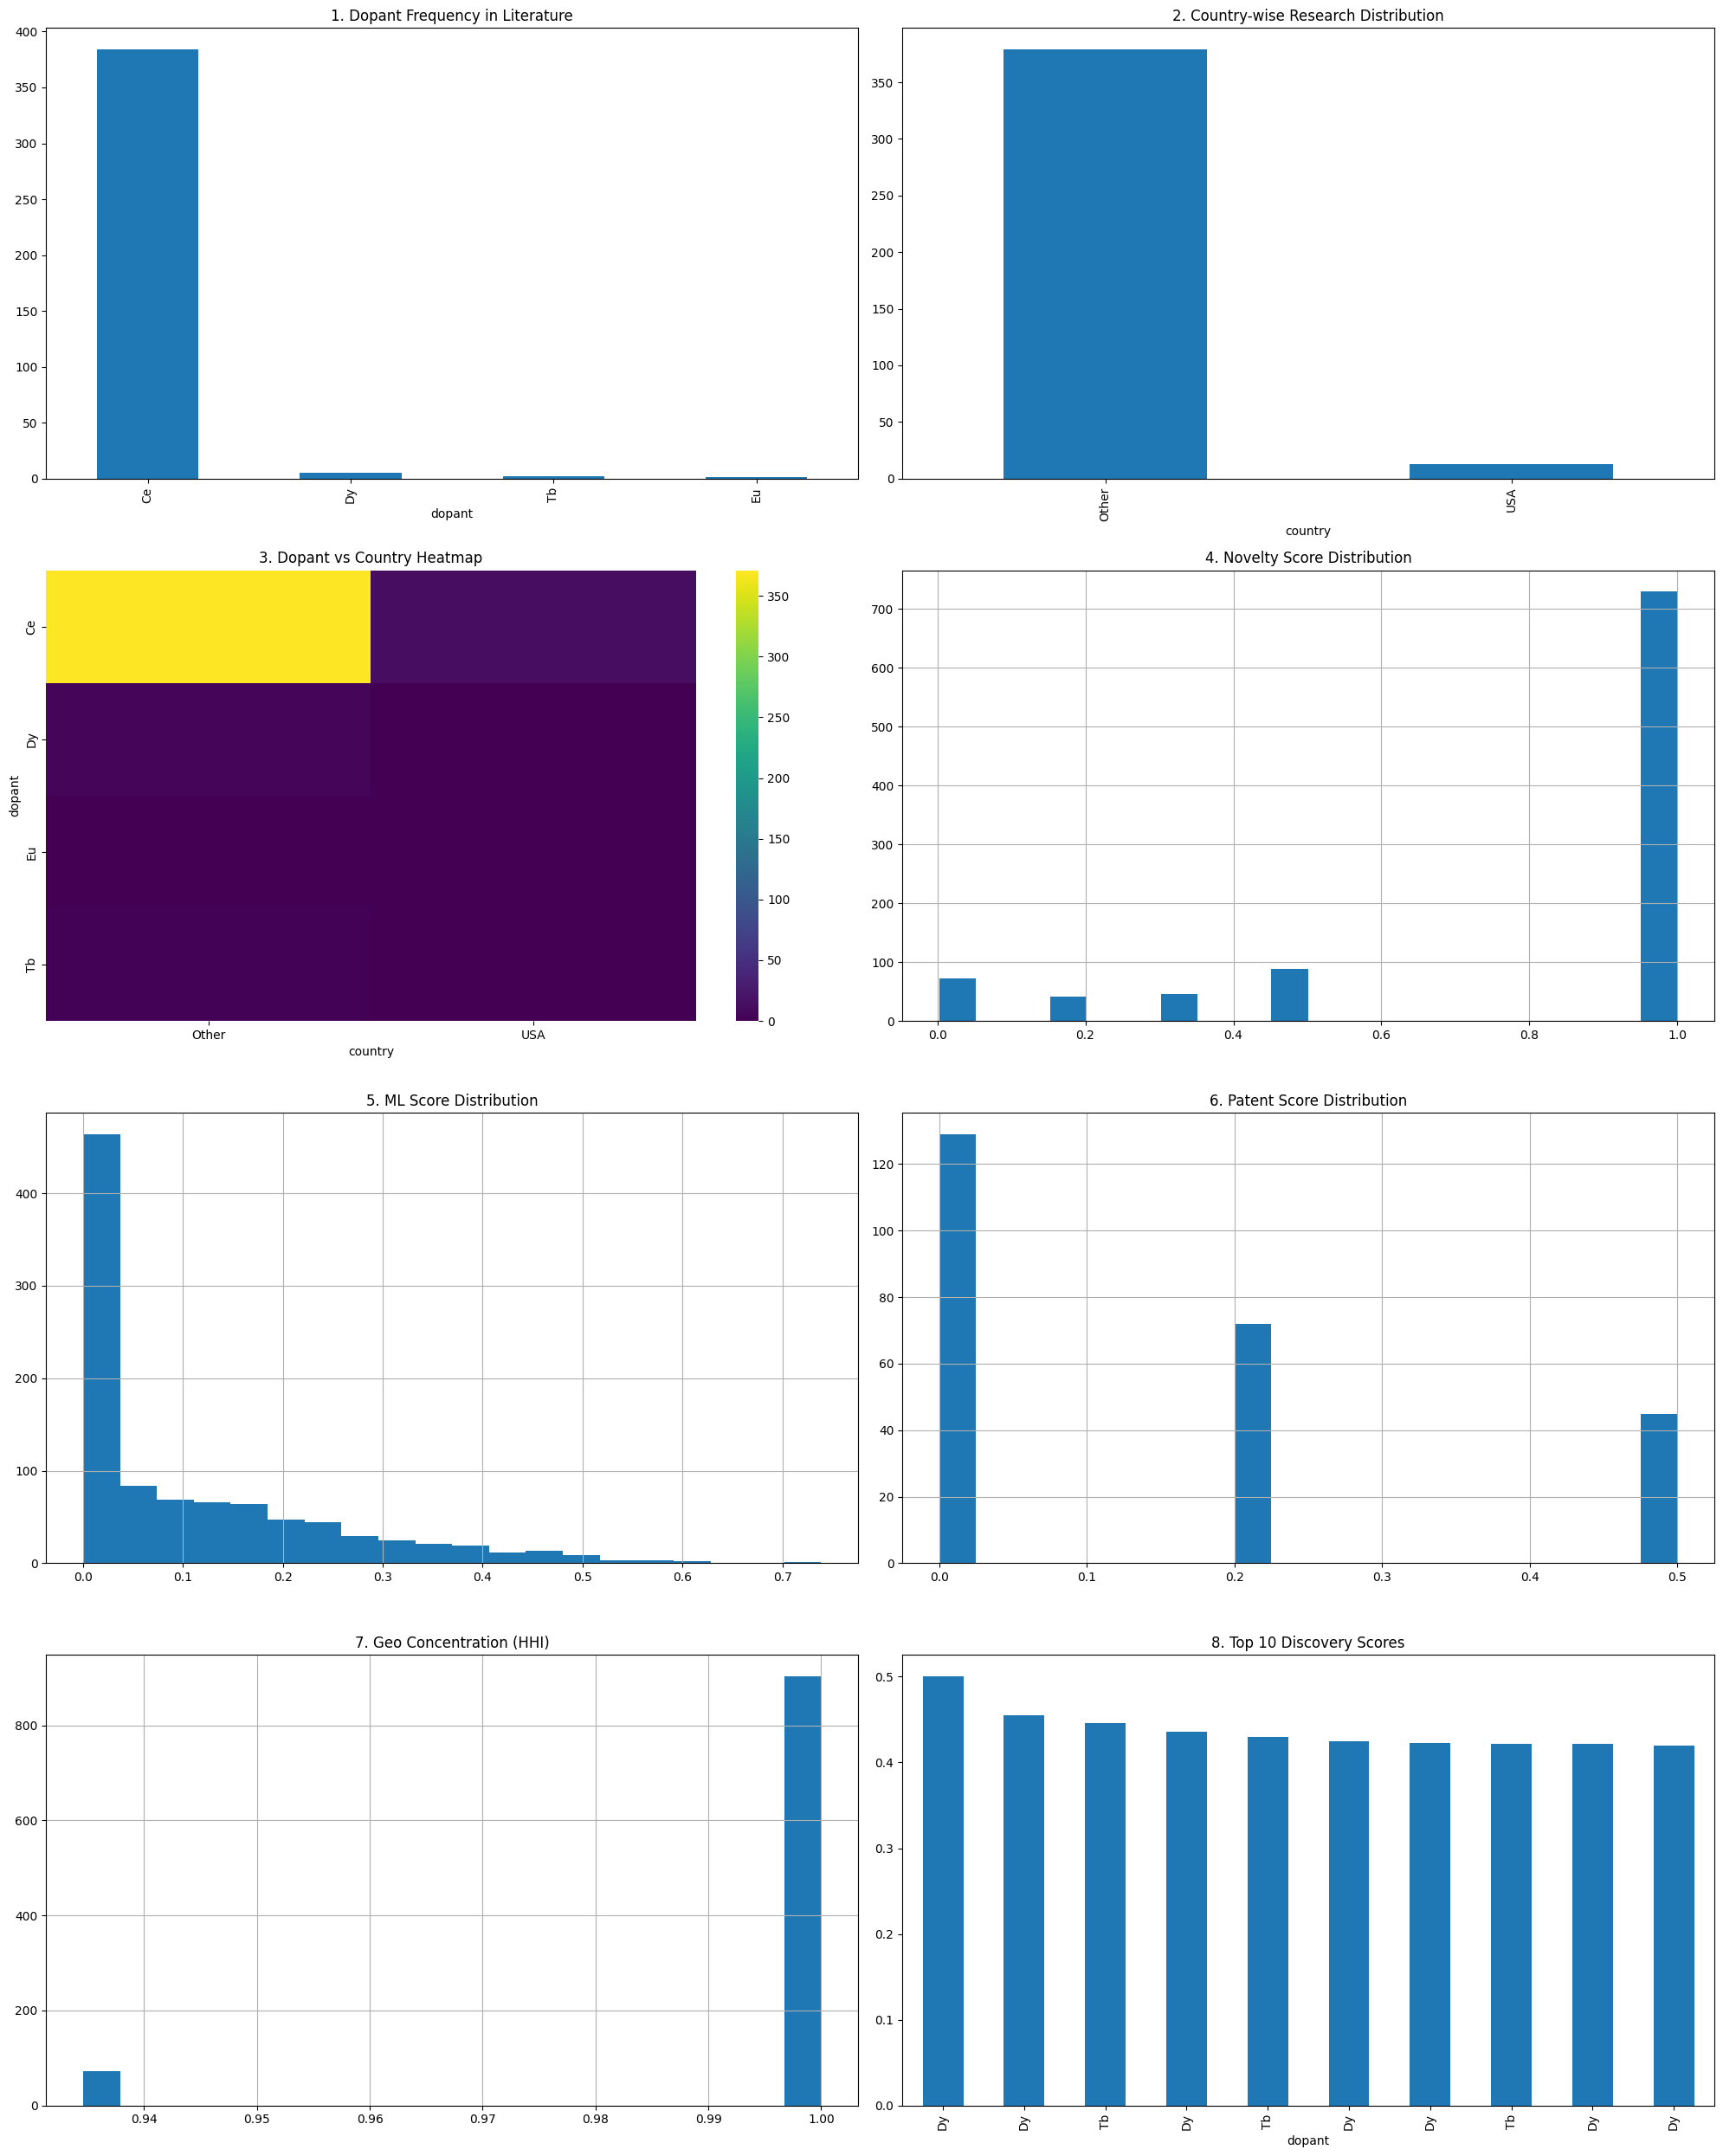

In [18]:
# ===== CELL 11: VISUAL ANALYTICS (8 GRAPHS) =====

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 25))

# 1️⃣ Dopant frequency (literature)
plt.subplot(4,2,1)
df_literature['dopant'].value_counts().plot(kind='bar')
plt.title("1. Dopant Frequency in Literature")

# 2️⃣ Country distribution
plt.subplot(4,2,2)
df_literature['country'].value_counts().plot(kind='bar')
plt.title("2. Country-wise Research Distribution")

# 3️⃣ Geo Heatmap
plt.subplot(4,2,3)
sns.heatmap(geo_matrix, cmap="viridis")
plt.title("3. Dopant vs Country Heatmap")

# 4️⃣ Novelty distribution
plt.subplot(4,2,4)
df['novelty'].hist(bins=20)
plt.title("4. Novelty Score Distribution")

# 5️⃣ ML score distribution
plt.subplot(4,2,5)
df['ml_score'].hist(bins=20)
plt.title("5. ML Score Distribution")

# 6️⃣ Patent score distribution
plt.subplot(4,2,6)
df['patent_score'].hist(bins=20)
plt.title("6. Patent Score Distribution")

# 7️⃣ Geo HHI (diversity)
plt.subplot(4,2,7)
df['geo_hhi'].hist(bins=20)
plt.title("7. Geo Concentration (HHI)")

# 8️⃣ Final discovery score (Top 10)
plt.subplot(4,2,8)
df.head(10).plot(
    x='dopant',
    y='score',
    kind='bar',
    legend=False,
    ax=plt.gca()
)
plt.title("8. Top 10 Discovery Scores")

plt.tight_layout()
plt.show()

In [19]:
# ===== CELL 12: SAVE EVERYTHING =====

SAVE_PATH = BASE + "/VENOM_FINAL"

import os
os.makedirs(SAVE_PATH, exist_ok=True)

df.to_csv(SAVE_PATH + "/full_results.csv", index=False)
geo_matrix.to_csv(SAVE_PATH + "/geo_matrix.csv")

print("✅ All results saved to:", SAVE_PATH)

✅ All results saved to: /content/drive/MyDrive/OSL_Research/VENOM_FINAL


In [20]:
# ===== ABSOLUTE FINAL DASHBOARD (FULL PIPELINE) =====

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("🚀 Building full pipeline from scratch...")

# -------------------------------
# STEP 1: LOAD DATA FROM DRIVE
# -------------------------------
BASE = "/content/drive/MyDrive/OSL_Research"

materials_path = BASE + "/osl_materials_unified.csv"
literature_path = BASE + "/osl_literature_unified.csv"

if not os.path.exists(materials_path) or not os.path.exists(literature_path):
    raise Exception("❌ Data files not found in Drive. Check path.")

df_materials = pd.read_csv(materials_path)
df_literature = pd.read_csv(literature_path)

print("✅ Data loaded")

# -------------------------------
# STEP 2: CLEAN
# -------------------------------
df_literature = df_literature.dropna(subset=['abstract'])

# -------------------------------
# STEP 3: DOPANT EXTRACTION
# -------------------------------
DOPANTS = ["Ce","Eu","Tb","Dy","Mn","Yb","Gd"]

def extract_dopant(text):
    for d in DOPANTS:
        if d.lower() in str(text).lower():
            return d
    return None

df_literature['dopant'] = df_literature['abstract'].apply(extract_dopant)
df_literature = df_literature.dropna(subset=['dopant'])

# -------------------------------
# STEP 4: GEO + PATENT
# -------------------------------
def get_country(text):
    text = str(text).lower()
    if "india" in text: return "India"
    if "china" in text: return "China"
    if "usa" in text: return "USA"
    return "Other"

df_literature['country'] = df_literature['abstract'].apply(get_country)

def patent_flag(text):
    return 1 if "patent" in str(text).lower() else 0

df_literature['patent'] = df_literature['abstract'].apply(patent_flag)

# -------------------------------
# STEP 5: GEO MATRIX
# -------------------------------
geo_matrix = pd.crosstab(df_literature['dopant'], df_literature['country'])

geo_norm = geo_matrix.div(geo_matrix.sum(axis=1), axis=0)
geo_hhi = (geo_norm**2).sum(axis=1)

india_gap = 1/(geo_matrix.get("India",0)+1)

geo_df = pd.DataFrame({
    "dopant": geo_matrix.index,
    "geo_hhi": geo_hhi,
    "india_gap": india_gap
})

# -------------------------------
# STEP 6: MATERIAL DOPANT
# -------------------------------
def extract_dopant_material(text):
    for d in DOPANTS:
        if d in str(text):
            return d
    return None

df_materials['dopant'] = df_materials['formula'].apply(extract_dopant_material)
df_materials = df_materials.dropna(subset=['dopant'])

# -------------------------------
# STEP 7: MERGE
# -------------------------------
df = df_materials.merge(geo_df, on="dopant", how="left")

# -------------------------------
# STEP 8: FEATURES
# -------------------------------
paper_count = df_literature['dopant'].value_counts()

df['novelty'] = 1/(df['dopant'].map(paper_count)+1)
df['ml_score'] = df['band_gap_eV']/10

patent_avg = df_literature.groupby("dopant")['patent'].mean()
df['patent_score'] = df['dopant'].map(patent_avg)

df['geo_hhi'] = df['geo_hhi'].fillna(1)
df['india_gap'] = df['india_gap'].fillna(1)

# -------------------------------
# STEP 9: FINAL SCORE
# -------------------------------
df['score'] = (
    0.35*df['ml_score'] +
    0.25*df['novelty'] +
    0.2*(1-df['geo_hhi']) +
    0.1*df['india_gap'] +
    0.1*(1-df['patent_score'])
)

df = df.sort_values(by="score", ascending=False)

print("✅ Pipeline ready")

# -------------------------------
# STEP 10: PLOTS
# -------------------------------
plt.figure(figsize=(22,28))

# 1
plt.subplot(4,2,1)
plt.scatter(df['novelty'], df['score'])
plt.title("Discovery vs Novelty")

# 2
plt.subplot(4,2,2)
plt.scatter(df['india_gap'], df['score'])
plt.title("India Opportunity")

# 3
plt.subplot(4,2,3)
plt.scatter(df['patent_score'], df['novelty'])
plt.title("Patent vs Novelty")

# 4
plt.subplot(4,2,4)
plt.scatter(df['ml_score'], df['score'])
plt.title("ML Contribution")

# 5
plt.subplot(4,2,5, polar=True)
top5 = df.head(5)
cats = ['ml_score','novelty','india_gap','patent_score','geo_hhi']
for _, row in top5.iterrows():
    vals = [row[c] for c in cats] + [row[cats[0]]]
    angles = np.linspace(0,2*np.pi,len(cats)+1)
    plt.plot(angles, vals, label=row['dopant'])
plt.legend()

# 6
plt.subplot(4,2,6)
sns.heatmap(df[['ml_score','novelty','geo_hhi','india_gap','patent_score','score']].corr(), annot=True)

# 7
plt.subplot(4,2,7)
plt.scatter(df['ml_score'], df['novelty'])
plt.title("Performance vs Novelty")

# 8
plt.subplot(4,2,8)
plt.scatter(df['novelty'], df['ml_score'], c=df['score'], cmap='viridis')
plt.colorbar(label="Score")
plt.title("Decision Space")

plt.tight_layout()
plt.show()

🚀 Building full pipeline from scratch...
✅ Data loaded


ValueError: 'dopant' is both an index level and a column label, which is ambiguous.